## 6. Model-Driven Data Exploration

Once a model is trained, we can use it to explore the dataset from the "model's perspective".
1. **Difficult Samples**: Identify which samples the model consistently misclassifies.
2. **Feature Similarity**: Use the last layer's activations (embeddings) to find samples that look similar to the model.

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

# Reload clean data
base_dir = 'spectrograms'
classes = ['class_0', 'class_1']
data = []
for cls in classes:
    path = os.path.join(base_dir, cls, '*.png')
    files = glob.glob(path)
    for f in files:
        data.append({'path': f, 'label': cls})
df_clean = pd.DataFrame(data)
print(f"Loaded {len(df_clean)} cleaned spectrograms.")


Loaded 2154 cleaned spectrograms.


In [8]:
import torch
import torch.nn as nn
from torchvision import transforms
from scipy.spatial.distance import cosine
import os
from model import CustomCNN, DeepCNN

# Wrapper to extract features for embedding analysis without duplicating model code
class FeatureExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.features
        # Extract the classifier up to the final linear layer to get the embedding
        self.classifier_head = nn.Sequential(*list(base_model.classifier.children())[:-1])
        self.final_layer = list(base_model.classifier.children())[-1]

    def forward(self, x):
        f = self.features(x)
        features_flat = self.classifier_head(f)
        logits = self.final_layer(features_flat)
        return logits, features_flat

device = torch.device("cpu")
base_model = CustomCNN()
if os.path.exists("models/CustomCNN.pth"):
    base_model.load_state_dict(torch.load("models/CustomCNN.pth", map_location=device), strict=False)
elif os.path.exists("CustomCNN.pth"):
    base_model.load_state_dict(torch.load("CustomCNN.pth", map_location=device), strict=False)

model = FeatureExtractor(base_model)
model.eval()
print("CustomCNN loaded from model.py and wrapped for exploration.")


CustomCNN loaded from model.py and wrapped for exploration.


Analyzing dataset for difficult samples...


100%|██████████| 2154/2154 [00:07<00:00, 280.75it/s]


Found 96 difficult samples.


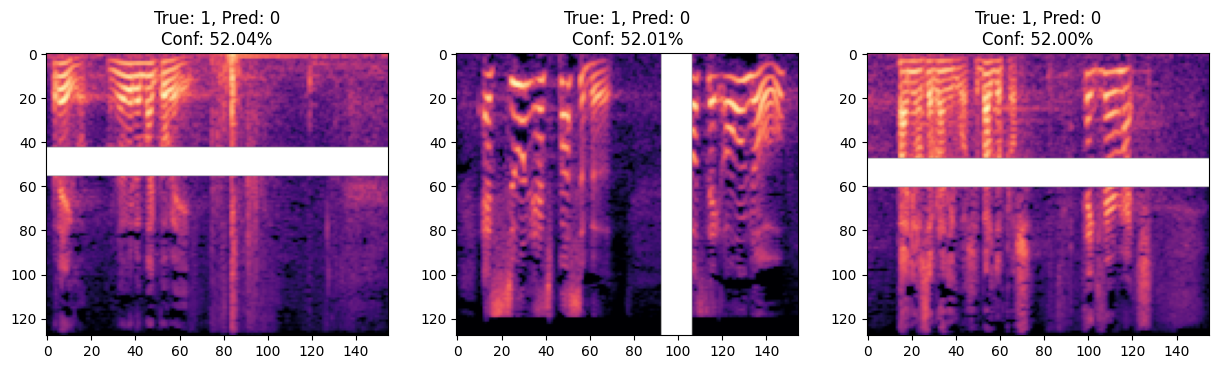

In [9]:
def get_prediction(img_path):
    img = Image.open(img_path).convert('L').resize((128, 128))
    tensor = transforms.ToTensor()(img).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5
    with torch.no_grad():
        logits, features = model(tensor)
        pred = torch.argmax(logits, dim=1).item()
        prob = torch.nn.functional.softmax(logits, dim=1)[0][pred].item()
    return pred, prob, features.numpy().flatten()

difficult_samples = []
embeddings = []

print("Analyzing dataset for difficult samples...")
for _, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    true_label = 1 if row['label'] == 'class_1' else 0
    pred_label, prob, feat = get_prediction(row['path'])
    embeddings.append(feat)
    if true_label != pred_label:
        difficult_samples.append({'path': row['path'], 'true': true_label, 'pred': pred_label, 'conf': prob})

df_difficult = pd.DataFrame(difficult_samples).sort_values('conf', ascending=False)
print(f"Found {len(df_difficult)} difficult samples.")

if not df_difficult.empty:
    plt.figure(figsize=(15, 5))
    for i in range(min(3, len(df_difficult))):
        plt.subplot(1, 3, i+1)
        img = Image.open(df_difficult.iloc[i]['path'])
        plt.imshow(img)
        plt.title(f"True: {df_difficult.iloc[i]['true']}, Pred: {df_difficult.iloc[i]['pred']}\nConf: {df_difficult.iloc[i]['conf']:.2%}")
    plt.show()

Finding samples with similar model activations...


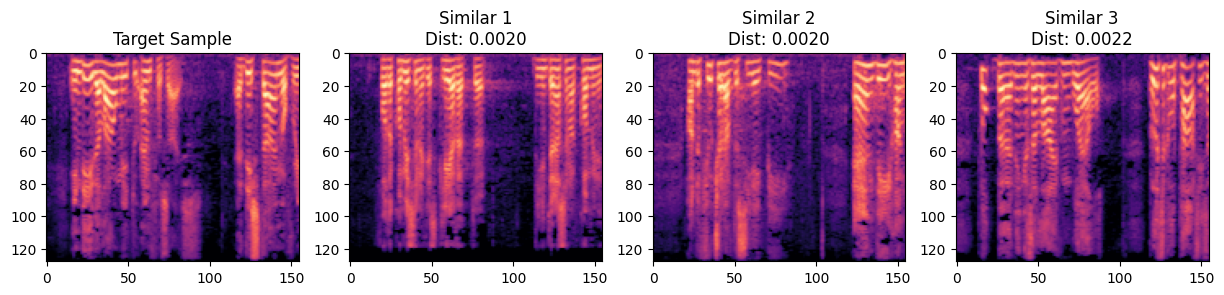

In [10]:
def find_similar_samples(idx, n=3):
    target_emb = embeddings[idx]
    distances = [cosine(target_emb, emb) for emb in embeddings]
    closest_indices = np.argsort(distances)[1:n+1]
    
    fig, ax = plt.subplots(1, n+1, figsize=(15, 5))
    ax[0].imshow(Image.open(df_clean.iloc[idx]['path']))
    ax[0].set_title("Target Sample")
    
    for i, sim_idx in enumerate(closest_indices):
        ax[i+1].imshow(Image.open(df_clean.iloc[sim_idx]['path']))
        ax[i+1].set_title(f"Similar {i+1}\nDist: {distances[sim_idx]:.4f}")
    plt.show()

print("Finding samples with similar model activations...")
find_similar_samples(0)